In [ ]:
import os
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, Subset,random_split
import numpy as np
from PIL import Image
from refinenet import RefineNet
import lightning as L
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from torch.utils.data import Subset
from lightning.pytorch.loggers import MLFlowLogger
from pathlib import Path
from torchvision import datasets, transforms
from torchvision.transforms import v2
from torchvision import tv_tensors

mask_dir= "masks/"
image_dir= "img/"


In [ ]:

class TransformSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset= subset
        self.transform= transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, mask =self.subset[idx]

        if self.transform:
            mask_wrapped =tv_tensors.Mask(mask.unsqueeze(0))
            image, mask_wrapped =self.transform(image, mask_wrapped)
            mask =mask_wrapped.squeeze(0).long() 

        return image, mask

In [ ]:

class RFIDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_transform=None):
        
        self.image_paths= sorted([
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.endswith('.png')
        ])
        self.mask_paths= sorted([
            os.path.join(mask_dir, f)
            for f in os.listdir(mask_dir)
            if f.endswith('.npy')
        ])

        
        for img_path, mask_path in zip(self.image_paths, self.mask_paths):
            img_stem=os.path.splitext(os.path.basename(img_path))[0]
            mask_stem=os.path.splitext(os.path.basename(mask_path))[0]
            assert img_stem == mask_stem, \
                f"Désalignement : {img_stem} vs {mask_stem}"

        self.img_transform =img_transform
        print(f"Dataset : {len(self.image_paths)} tuiles")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        
        image=np.array(Image.open(self.image_paths[idx]).convert('RGB'))
        image=torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        mask=np.load(self.mask_paths[idx]).astype(np.int64)
        mask=torch.from_numpy(mask).long()
        

        if self.img_transform:
            mask=v2.functional.to_image(mask.unsqueeze(0))  # (1, H, W)
            image, mask=self.transform(image, v2.Mask(mask))
            mask=mask.squeeze(0).long()                     # retour (H, W) int64

        return image, mask
    


dataset=RFIDataset(image_dir, mask_dir, img_transform=None)
image, mask= dataset[0]  
print(f"Image shape : {image.shape}, dtype : {image.dtype}")
print(f"Mask shape : {mask.shape},  dtype : {mask.dtype}")
print(f"Mask valeurs uniques : {torch.unique(mask)}")

Dataset : 5040 tuiles
Image shape : torch.Size([3, 64, 64]), dtype : torch.float32
Mask shape  : torch.Size([64, 64]),  dtype : torch.int64
Mask valeurs uniques : tensor([0, 1])


In [ ]:

dataset = RFIDataset(image_dir, mask_dir, img_transform=None)


test_size = 0.30
test_amount= int(len(dataset) * test_size)
train_sub, test_sub= random_split(
    dataset,
    [len(dataset) - test_amount, test_amount],
    generator=torch.Generator().manual_seed(42)
)


train_transform=v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomVerticalFlip(),
    v2.GaussianBlur(kernel_size=3),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform=v2.Compose([
    v2.Resize((224, 224)),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_set=TransformSubset(train_sub, transform=train_transform)
test_set =TransformSubset(test_sub,  transform=test_transform)

train_set_small=Subset(train_set, range(200))


B = 8#128
train_dataloader= DataLoader(train_set_small, batch_size=B, shuffle=True, num_workers=0)
#train_dataloader = DataLoader(train_set, batch_size=B, shuffle=True,  num_workers=4)
test_dataloader=DataLoader(test_set,  batch_size=B, shuffle=False, num_workers=0)

Dataset : 5040 tuiles


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

def double_convolution(in_channels, out_channels):

    conv_op = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )
    return conv_op


Device : cpu


In [ ]:
L.seed_everything(42)
class LitResNet18(L.LightningModule):
    def __init__(self, num_classes=2, lr=1e-3, freeze_backbone=True, dropout_p=0.0):
        super().__init__()
        self.save_hyperparameters()

        # Encodeur 
        weights =ResNet18_Weights.DEFAULT
        backbone = resnet18(weights=weights)

        
        self.enc_stem=nn.Sequential(
            backbone.conv1,   # Conv7×7 stride2
            backbone.bn1,
            backbone.relu,
            )               

        self.enc_pooln=backbone.maxpool  # MaxPool stride2
                                        

        self.enc_layer1 =backbone.layer1 
        self.enc_layer2 =backbone.layer2 
        self.enc_layer3 =backbone.layer3 
        self.enc_layer4 =backbone.layer4  

        if freeze_backbone:
            for module in [self.enc_stem, self.enc_pool,
            self.enc_layer1, self.enc_layer2,
            self.enc_layer3, self.enc_layer4]:
                for param in module.parameters():
                    param.requires_grad = False

        #Décodeur (symétrique)
        
        self.dec_block4=nn.Sequential(
        nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2,padding=1, output_padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(256),
        nn.ConvTranspose2d(256, 256, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(256),
        )

        
        self.dec_block3=nn.Sequential(
        nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2,padding=1, output_padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(128),
        nn.ConvTranspose2d(128, 128, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(128),
        ) 

        
        self.dec_block2=nn.Sequential(
        nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2,padding=1, output_padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(64),
        nn.ConvTranspose2d(64, 64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(64),
        )

        
        self.dec_block1=nn.Sequential(
        nn.ConvTranspose2d(64, 64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(64),
        nn.ConvTranspose2d(64, 64, kernel_size=3, stride=1, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(64),
        )

        
        self.dec_upsample=nn.Upsample(scale_factor=2, mode='bilinear',align_corners=False)
        

        
        self.dec_stem=nn.Sequential(
        nn.ConvTranspose2d(64, 64, kernel_size=7, stride=2,padding=3, output_padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(64),
        ) 

        
        self.seg_head=nn.Sequential(
        nn.Dropout2d(p=dropout_p),
        nn.Conv2d(64, num_classes, kernel_size=1)
        ) 
        self.iou = BinaryJaccardIndex() 
        self.f1  = BinaryF1Score()  
        self.criterion=nn.CrossEntropyLoss()

    def forward(self, x):
        # Encodeur
        e1 =self.enc_stem(x)
        e2 =self.enc_pool(e1)
        e3 =self.enc_layer1(e2)
        e4 =self.enc_layer2(e3)
        e5 =self.enc_layer3(e4)
        e6 =self.enc_layer4(e5)
        # Décodeur
        d1 =self.dec_block4(e6)
        d2 =self.dec_block3(d1)
        d3 =self.dec_block2(d2)
        d4 =self.dec_block1(d3)
        d5 =self.dec_upsample(d4)
        d6 =self.dec_stem(d5)
        return self.seg_head(d6)

    def training_step(self, batch, batch_idx):
        x, y =batch
        preds=self(x) 
        loss=self.criterion(preds, y)
        acc=(preds.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, on_step=True, on_epoch=True)
        self.log("train_acc",  acc,  on_step=True, on_epoch=True)
        return loss
    
    
    def test_step(self, batch, batch_idx):
        x, y =batch
        preds=self(x).argmax(dim=1)
        acc=(y == preds).float().mean()
        self.log("test_acc", acc, prog_bar=True, on_epoch=True)
        preds_mask = preds.argmax(dim=1)   
        iou = self.iou(preds_mask, y)
        f1  = self.f1(preds_mask, y)
        self.log("test_iou", iou, prog_bar=True, on_epoch=True)
        self.log("test_f1",  f1,  prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        params = filter(lambda p: p.requires_grad, self.parameters())
        return torch.optim.Adam(params, lr=self.hparams.lr)

Seed set to 42


In [ ]:
mlf_logger =MLFlowLogger(
    experiment_name="resnet18_rfi",
    tracking_uri="sqlite:///mlflow.db",
    log_model=True
)
checkpoint_cb =ModelCheckpoint(
    monitor="train_loss_epoch",
    mode="min",
    save_top_k=1,
    filename="best-{epoch:02d}-{train_loss_epoch:.3f}"
)
early_stop_cb=EarlyStopping(
    monitor="train_loss_epoch",
    mode="min",
    patience=3
)
model=LitResNet18(
    num_classes=2,
    lr=1e-3,
    freeze_backbone=True,
    dropout_p=0.3
)
#trainer = L.Trainer(
#    max_epochs=5,
#    logger=mlf_logger,
#    callbacks=[checkpoint_cb, early_stop_cb]
#)
trainer =L.Trainer(
    max_epochs=10,
    precision="16-mixed",
    logger=mlf_logger,
    callbacks=[checkpoint_cb, early_stop_cb]
)
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=None)

2026/06/17 10:22:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/17 10:22:43 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

Epoch 1: 100%|██████████| 25/25 [51:15<00:00,  0.01it/s, v_num=7a31]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 25/25 [51:15<00:00,  0.01it/s, v_num=7a31]


In [ ]:
results=trainer.test(model, dataloaders=test_dataloader)
print(results)

/Users/rzouhhad/Nextcloud/docu_cloud/venv/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 189/189 [30:27<00:00,  0.10it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8919905424118042
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'test_acc': 0.8919905424118042}]


In [ ]:
model.eval()
model.freeze()

# Récupère un batch du test set
batch =next(iter(test_dataloader))
x, y =batch

with torch.no_grad():
    preds=model(x)
    preds_mask=preds.argmax(dim=1) 

# Affiche n exemples
n = 4
fig, axes =plt.subplots(n, 3, figsize=(12, n * 4))
axes[0, 0].set_title("Image")
axes[0, 1].set_title("Masque GT")
axes[0, 2].set_title("Prédiction")

for i in range(n):
    
    img =x[i].cpu().permute(1, 2, 0).numpy()
    mean=np.array([0.485, 0.456, 0.406])
    std=np.array([0.229, 0.224, 0.225])
    img=(img * std + mean).clip(0, 1)

    axes[i, 0].imshow(img)
    axes[i, 0].axis("off")

    # Masque ground truth
    axes[i, 1].imshow(y[i].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[i, 1].axis("off")

    # Prédiction
    axes[i, 2].imshow(preds_mask[i].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()

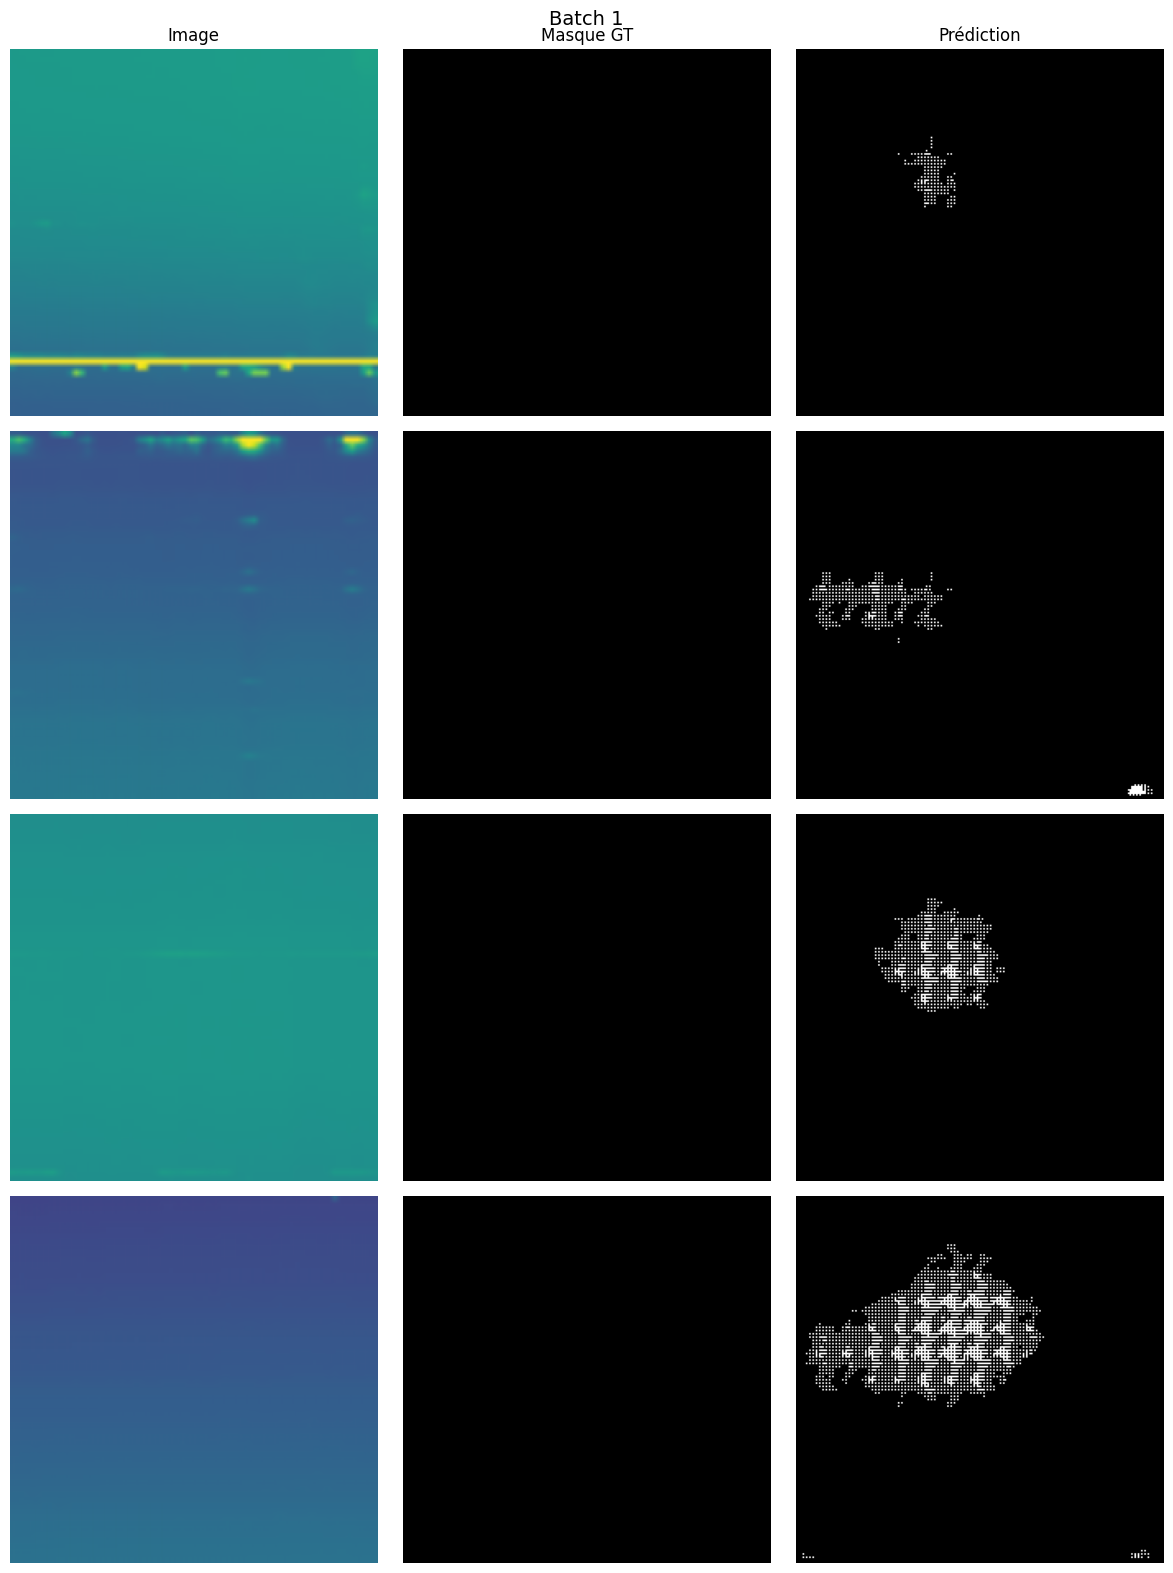

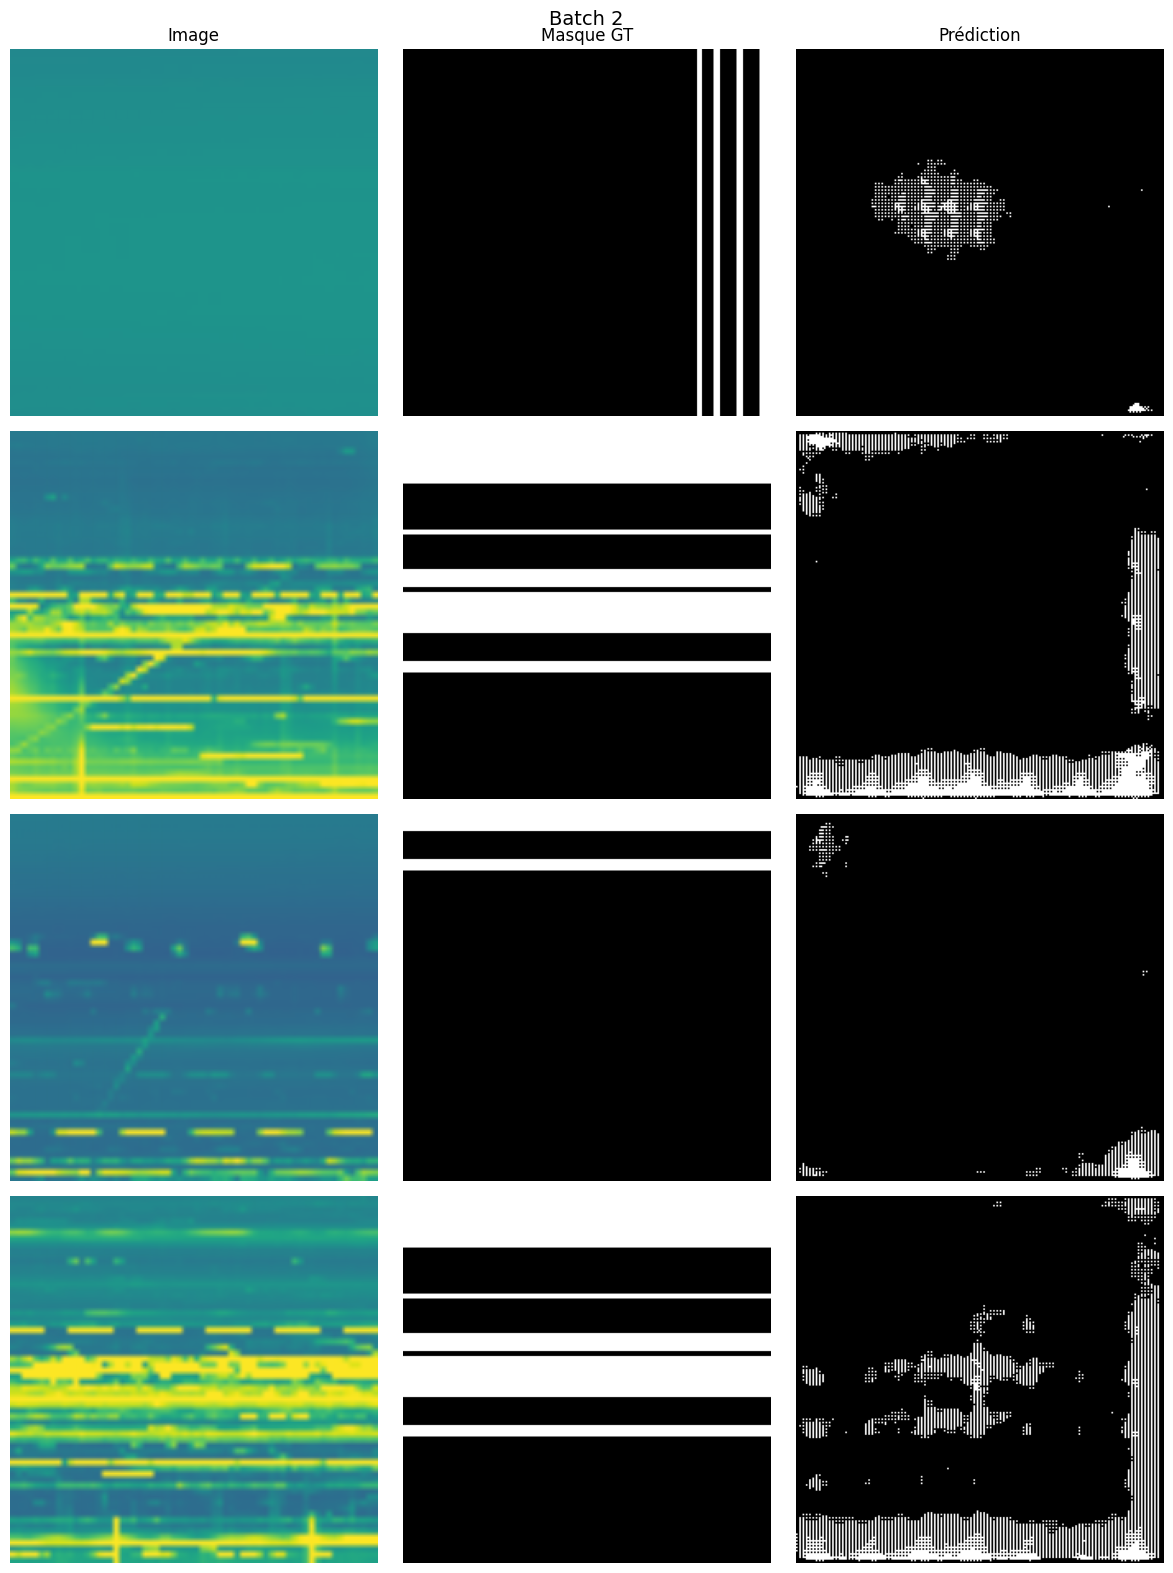

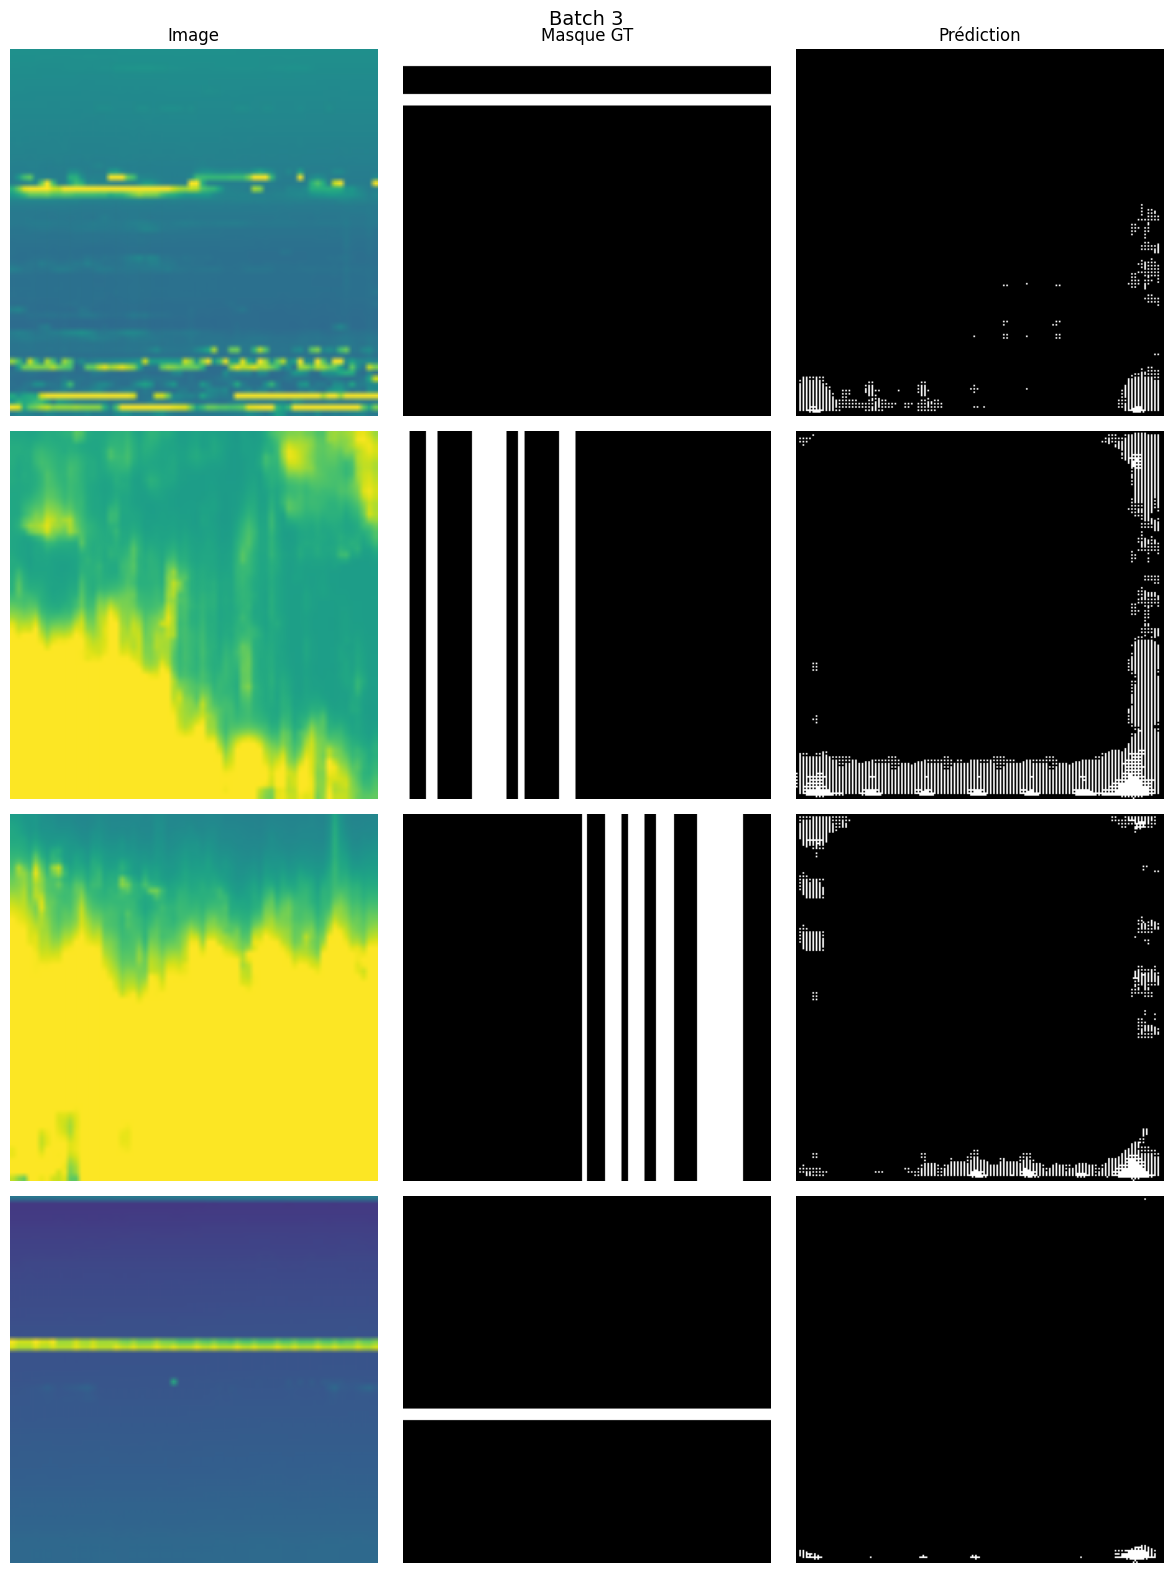

In [ ]:
n_batches=3  # nombre de batches à visualiser
n_per_batch=4

for batch_idx, (x, y) in enumerate(test_dataloader):
    if batch_idx >= n_batches:
        break

    with torch.no_grad():
        preds= model(x)
        preds_mask =preds.argmax(dim=1)

    fig, axes =plt.subplots(n_per_batch, 3, figsize=(12, n_per_batch * 4))
    fig.suptitle(f"Batch {batch_idx + 1}", fontsize=14)
    axes[0, 0].set_title("Image")
    axes[0, 1].set_title("Masque GT")
    axes[0, 2].set_title("Prédiction")

    for i in range(n_per_batch):
        img=x[i].cpu().permute(1, 2, 0).numpy()
        img=(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].axis("off")
        axes[i, 1].imshow(y[i].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[i, 1].axis("off")
        axes[i, 2].imshow(preds_mask[i].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig(f"predictions_batch{batch_idx + 1}.png", dpi=150)
    plt.show()

import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np

from torchvision.io import decode_image


# Setup path to data folder
mask_dir  = "mask/" 
image_dir = "img/"

class CustomDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_transform=None):
        # garantir que image[i] et mask[i] correspondent toujours.
        self.image_paths = sorted((os.path.join(image_dir, '*.*')))
        self.mask_paths  = sorted((os.path.join(mask_dir,  '*.*')))
        #self.transform   = img_transform
        # Vérification de cohérence : autant d'images que de masques
        assert len(self.image_paths) == len(self.mask_paths), \
            'Nombre images / masques différent'

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Lecture de l'image
        with open(self.image_paths[idx]) as src:
            image = src.read()

        # Lecture du masque binaire 
        with open(self.mask_paths[idx]) as src:
            mask = src.read()

        #if self.transform:

        #else:


        return image, mask

print('Dataset établis')


dataset = CustomDataset(image_dir, mask_dir)
data, sample = dataset.__getitem__(0) # get data at index 0